# ML Challenge 

<img src="https://imageio.forbes.com/specials-images/imageserve/5ecd179f798e4c00060d2c7c/0x0.jpg?format=jpg&height=600&width=1200&fit=bounds" width="500" height="300">

In the bustling city of Financia, the Central Lending Institution (CLI) is the largest provider of loans to individuals and businesses. With a mission to support economic growth and financial stability, CLI processes thousands of loan applications every month. However, the traditional manual review process is time-consuming and prone to human error, leading to delays and inconsistencies in loan approvals.
To address these challenges, CLI has decided to leverage the power of machine learning to streamline their loan approval process. They have compiled a comprehensive dataset containing historical loan application records, including various factors such as credit scores, income levels, employment status, loan terms(measured in years), loan amounts, asset values, and the final loan status (approved or denied).


**Your task is to develop a predictive model that can accurately determine the likelihood of loan approval based on the provided features. By doing so, you will help CLI make faster, more accurate, and fairer lending decisions, ultimately contributing to the financial well-being of the community.**

It is recommended that you follow the typical machine learning workflow, though you are not required to strictly follow each steps: 
1. Data Collection: Gather the data you need for your model. (Already done for you)

2. Data Preprocessing: Clean and prepare the data for analysis. (Already done for you)

3. Exploratory Data Analysis (EDA): Understand the data and its patterns. (Partially done for you)

4. Feature Engineering: Create new features or modify existing ones to improve model performance. (Partially done for you)

5. Model Selection: Choose the appropriate machine learning algorithm.

6. Model Training: Train the model using the training dataset.

7. Model Evaluation: Evaluate the model's performance using a validation dataset.

8. Model Optimization: Optimize the model's parameters to improve performance.

9. Model Testing: Test the final model on a separate test dataset.

**Please include ALL your work and thought process in this notebook**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score, log_loss,
                             classification_report, ConfusionMatrixDisplay)

SEED = 42
plt.rcParams.update({"figure.figsize": (9, 5), "font.size": 11})

## Dataset


In [2]:
# DO NOT MODIFY
loan_data = pd.read_csv("../../data/loan_approval.csv")


## EDA
Uncomment to see desired output. Add more analysis if you like

Applications: 4,269; columns: 13


,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


loan_id                     0
no_of_dependents            0
education                   0
self_employed               0
income_annum                0
loan_amount                 0
loan_term                   0
cibil_score                 0
residential_assets_value    0
commercial_assets_value     0
luxury_assets_value         0
bank_asset_value            0
loan_status                 0
Name: Missing values, dtype: int64

Train: 2561, validation: 854, test: 854


,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,2561.00,2561.00,2561.00,2561.00,2561.00,2561.00,2561.00,2561.00,2561.00,2561.00
mean,2151.86,2.47,5035025.38,14996017.18,10.92,598.35,7374814.53,4962944.16,15069426.01,4939711.05
std,1236.46,1.71,2804207.79,8974411.09,5.68,171.40,6370486.32,4330217.83,9105722.27,3240831.50
min,1.00,0.00,200000.00,300000.00,2.00,300.00,-100000.00,0.00,300000.00,0.00
25%,1079.00,1.00,2600000.00,7600000.00,6.00,453.00,2200000.00,1400000.00,7300000.00,2300000.00
50%,2171.00,2.00,5100000.00,14400000.00,10.00,597.00,5600000.00,3700000.00,14400000.00,4500000.00
75%,3230.00,4.00,7500000.00,21300000.00,16.00,745.00,11200000.00,7700000.00,21700000.00,7000000.00
max,4269.00,5.00,9900000.00,39500000.00,20.00,900.00,28700000.00,18900000.00,39200000.00,14700000.00


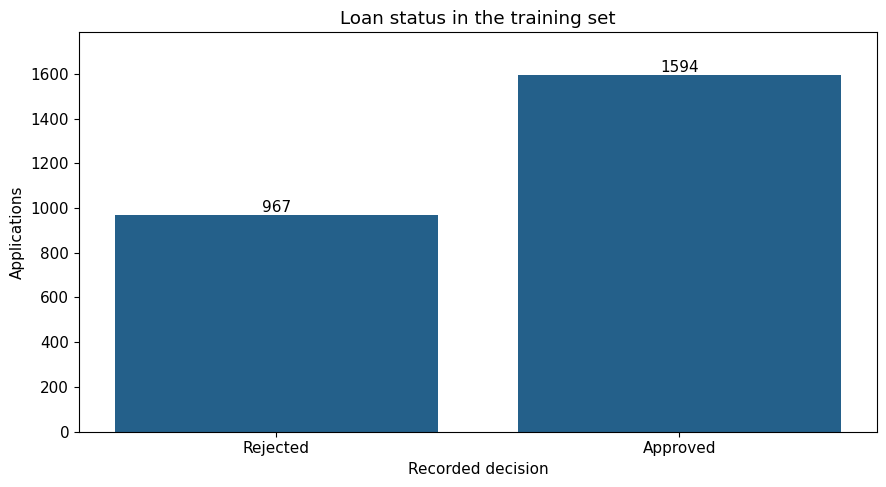

Training approval rate: 62.2%


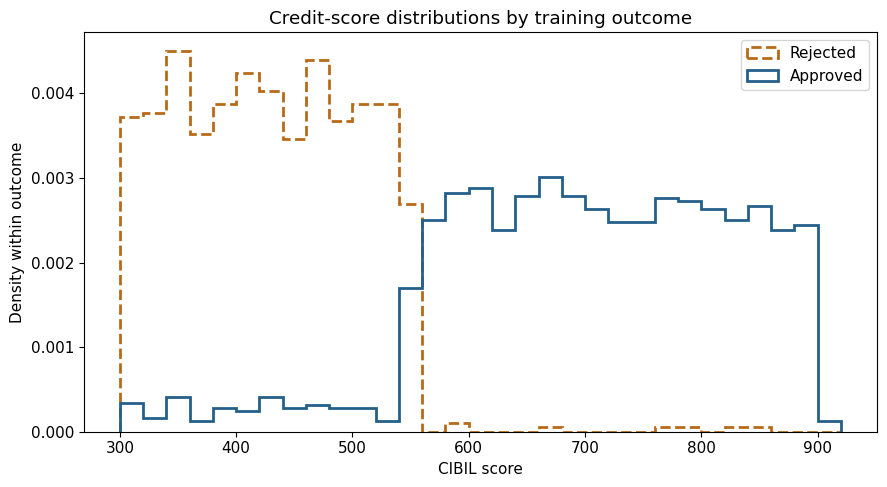

,median,mean
loan_status,,
Approved,705.5,701.2
Rejected,427.0,428.7


In [3]:
# Inspect schema and integrity before splitting; loan_id is an identifier, not a predictor.
print(f"Applications: {len(loan_data):,}; columns: {loan_data.shape[1]}")
display(loan_data.head())
display(loan_data.isna().sum().rename("Missing values"))
assert loan_data["loan_id"].is_unique
assert not loan_data.drop(columns="loan_id").duplicated().any()
assert loan_data["loan_status"].isin(["Approved", "Rejected"]).all()

# Reserve 20% for final testing, then 20% for validation (60% training overall).
# Stratification preserves the class balance. Perform outcome-related EDA on training only.
train_val, test_data = train_test_split(loan_data, test_size=0.2, random_state=SEED,
                                      stratify=loan_data["loan_status"])
train_data, validation_data = train_test_split(train_val, test_size=0.25, random_state=SEED,
                                              stratify=train_val["loan_status"])
print(f"Train: {len(train_data)}, validation: {len(validation_data)}, test: {len(test_data)}")
display(train_data.describe().round(2))
counts = train_data["loan_status"].value_counts().reindex(["Rejected", "Approved"])
fig, ax = plt.subplots()
ax.bar(counts.index, counts.values, color="#24608a")
ax.set(title="Loan status in the training set", xlabel="Recorded decision", ylabel="Applications")
for i, value in enumerate(counts): ax.text(i, value, str(value), ha="center", va="bottom")
ax.set_ylim(0, counts.max() * 1.12)
fig.tight_layout()
plt.show()
print(f"Training approval rate: {(train_data.loan_status == 'Approved').mean():.1%}")

fig, ax = plt.subplots()
for status, color in [("Rejected", "#b86a19"), ("Approved", "#24608a")]:
    ax.hist(train_data.loc[train_data.loan_status == status, "cibil_score"],
            bins=np.arange(300, 921, 20), density=True, histtype="step", linewidth=2,
            linestyle="--" if status == "Rejected" else "-", label=status, color=color)
ax.set(title="Credit-score distributions by training outcome", xlabel="CIBIL score", ylabel="Density within outcome")
ax.legend()
fig.tight_layout()
plt.show()
display(train_data.groupby("loan_status")["cibil_score"].agg(["median", "mean"]).round(1))

The class-count chart checks imbalance, motivating a majority baseline and metrics beyond accuracy. The credit-score density chart compares the shapes within each outcome, so differing class sizes do not dominate. Only training observations are used for these plots. The training approval rate is 62.2%, so always predicting approval is a meaningful accuracy baseline. Approved applications tend to have higher credit scores, although the distributions overlap.

## Feature Engineering

You may want to convert categorical variables to numerical. For example, education takes on the value Graduate and Not Graduate. But we want it to be 0 or 1 for machine learning algorithms to use.

In [4]:
def make_features(data):
    # Transform each row independently; no statistics are learned before the split.
    X = data.drop(columns=["loan_id", "loan_status"]).copy()
    for column, mapping in {
        "education": {"Graduate": 1, "Not Graduate": 0},
        "self_employed": {"Yes": 1, "No": 0},
    }.items():
        assert X[column].isin(mapping).all(), f"Unexpected category in {column}"
        X[column] = X[column].map(mapping)
    # Relative loan burden is comparable across income levels; invalid denominators become NaN.
    X["loan_to_income"] = X["loan_amount"] / X["income_annum"].where(X["income_annum"] > 0)
    return X

X_train = make_features(train_data)
X_val = make_features(validation_data)
y_train = train_data["loan_status"].map({"Rejected": 0, "Approved": 1})
y_val = validation_data["loan_status"].map({"Rejected": 0, "Approved": 1})
assert set(train_data.index).isdisjoint(validation_data.index)
assert set(train_val.index).isdisjoint(test_data.index)

Education and self-employment are encoded as binary categories. `loan_to_income` captures relative loan size without assuming a currency unit or that loan payments equal principal divided by term. Loan ID is excluded because it identifies records rather than applicant characteristics.

## Model Selection

You are free to use any classification machine learning models you like: Logistic Regression, Decision Trees/Random Forests, Support Vector Machines, KNN ... 

Logistic regression provides a simple linear comparison; a random forest can capture thresholds and interactions. Validation ROC AUC selects the model family; cross-validation on training data tunes its parameters. The fixed 0.5 threshold is an exercise default, not a business-optimal decision rule.

In [5]:
# Pipelines learn imputation/scaling only from each training fold.
models = {
    "Majority baseline": DummyClassifier(strategy="most_frequent"),
    "Logistic regression": make_pipeline(SimpleImputer(strategy="median"), StandardScaler(),
                                         LogisticRegression(max_iter=2000, random_state=SEED)),
    "Random forest": make_pipeline(SimpleImputer(strategy="median"),
                                   RandomForestClassifier(n_estimators=150, random_state=SEED, n_jobs=1)),
}

def evaluate(estimator, X, y):
    # Approved is the positive class; use a fixed 0.5 probability threshold.
    probability = estimator.predict_proba(X)[:, 1]
    predicted = (probability >= 0.5).astype(int)
    return {"Accuracy": accuracy_score(y, predicted),
            "Balanced accuracy": balanced_accuracy_score(y, predicted),
            "Precision": precision_score(y, predicted, zero_division=0),
            "Recall": recall_score(y, predicted, zero_division=0),
            "F1": f1_score(y, predicted), "ROC AUC": roc_auc_score(y, probability),
            "Log loss": log_loss(y, probability)}

## Model Training and Evaluation

In [6]:
# Select by validation ROC AUC, which measures ranking across thresholds.
validation_results = {}
for name, estimator in models.items():
    estimator.fit(X_train, y_train)
    validation_results[name] = evaluate(estimator, X_val, y_val)
validation_results = pd.DataFrame(validation_results).T
selected_name = validation_results["ROC AUC"].idxmax()
display(validation_results.round(4))
print(f"Selected model: {selected_name}")

,Accuracy,Balanced accuracy,Precision,Recall,F1,ROC AUC,Log loss
Majority baseline,0.6218,0.5000,0.6218,1.0000,0.7668,0.5000,13.6324
Logistic regression,0.9016,0.8985,0.9290,0.9115,0.9202,0.9598,0.2486
Random forest,0.9953,0.9938,0.9925,1.0000,0.9962,0.9990,0.0504


Selected model: Random forest


## Model Optimization and Testing

Best parameters: {'randomforestclassifier__max_depth': None, 'randomforestclassifier__max_features': 1.0, 'randomforestclassifier__min_samples_leaf': 3}
Mean training-CV ROC AUC: 0.9992


,Accuracy,Balanced accuracy,Precision,Recall,F1,ROC AUC,Log loss
Initial,0.9953,0.9938,0.9925,1.0,0.9962,0.999,0.0504
Tuned,0.9953,0.9938,0.9925,1.0,0.9962,0.998,0.0568


Use tuned model: False


,Accuracy,Balanced accuracy,Precision,Recall,F1,ROC AUC,Log loss
Final model,0.9965,0.9954,0.9944,1.0,0.9972,0.9993,0.0425
Majority baseline,0.6218,0.5000,0.6218,1.0,0.7668,0.5000,13.6324


              precision    recall  f1-score   support

    Rejected      1.000     0.991     0.995       323
    Approved      0.994     1.000     0.997       531

    accuracy                          0.996       854
   macro avg      0.997     0.995     0.996       854
weighted avg      0.997     0.996     0.996       854



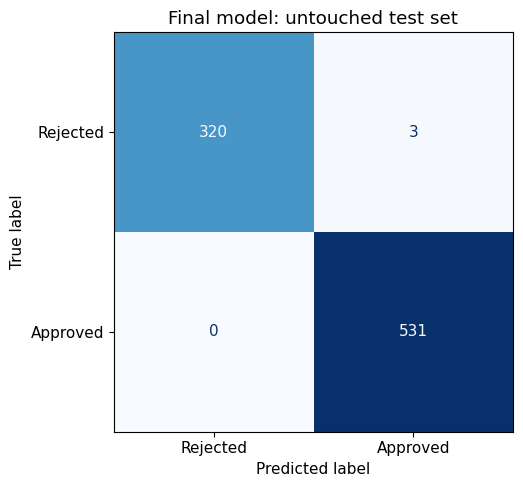

,loan_id,observed_status,approval_score,predicted_status
2346,2347,Approved,0.993333,Approved
1162,1163,Approved,0.980000,Approved
3061,3062,Approved,0.993333,Approved
483,484,Rejected,0.026667,Rejected
2102,2103,Approved,0.993333,Approved


In [7]:
# Tune only the selected family using stratified cross-validation within training data.
parameter_grids = {
    "Random forest": {"randomforestclassifier__max_depth": [None, 8, 16],
                      "randomforestclassifier__min_samples_leaf": [1, 3],
                      "randomforestclassifier__max_features": ["sqrt", 1.0]},
    "Logistic regression": {"logisticregression__C": [0.01, 0.1, 1.0, 10.0]},
    "Majority baseline": {},
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
search = GridSearchCV(models[selected_name], parameter_grids[selected_name],
                      scoring="roc_auc", cv=cv, n_jobs=1)
search.fit(X_train, y_train)
print("Best parameters:", search.best_params_)
print(f"Mean training-CV ROC AUC: {search.best_score_:.4f}")
display(pd.DataFrame({"Initial": evaluate(models[selected_name], X_val, y_val),
                      "Tuned": evaluate(search.best_estimator_, X_val, y_val)}).T.round(4))

# Keep the tuned version only if its validation AUC is at least as good.
from sklearn.base import clone
use_tuned = evaluate(search.best_estimator_, X_val, y_val)["ROC AUC"] >= validation_results.loc[selected_name, "ROC AUC"]
final_model = clone(search.best_estimator_ if use_tuned else models[selected_name])
print("Use tuned model:", use_tuned)
# Freeze choices, refit on train+validation, then evaluate the test set once.
X_train_val = make_features(train_val)
y_train_val = train_val.loan_status.map({"Rejected": 0, "Approved": 1})
final_model.fit(X_train_val, y_train_val)
X_test = make_features(test_data)
y_test = test_data.loan_status.map({"Rejected": 0, "Approved": 1})
test_metrics = evaluate(final_model, X_test, y_test)
final_baseline = DummyClassifier(strategy="most_frequent").fit(X_train_val, y_train_val)
display(pd.DataFrame({"Final model": test_metrics,
                      "Majority baseline": evaluate(final_baseline, X_test, y_test)}).T.round(4))
test_probability = final_model.predict_proba(X_test)[:, 1]
test_prediction = (test_probability >= 0.5).astype(int)
print(classification_report(y_test, test_prediction, target_names=["Rejected", "Approved"], digits=3))
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, test_prediction, display_labels=["Rejected", "Approved"],
                                        cmap="Blues", colorbar=False, ax=ax)
ax.set_title("Final model: untouched test set")
fig.tight_layout()
plt.show()
# Illustrate probability output; these scores are not guaranteed calibrated probabilities.
display(pd.DataFrame({"loan_id": test_data.loan_id,
                      "observed_status": test_data.loan_status,
                      "approval_score": test_probability,
                      "predicted_status": np.where(test_prediction == 1, "Approved", "Rejected")}).head())

## Interpretation and limitations

The random forest outperformed logistic regression on validation ROC AUC (0.9990 versus 0.9598). The parameter search achieved mean training cross-validation AUC of 0.9992, but its chosen settings reduced validation AUC to 0.9980. Therefore, the initial random forest was retained and refitted on training plus validation data.

On the **854 untouched test applications**, the final model achieved **99.65% accuracy**, **0.9972 F1**, **0.9993 ROC AUC**, and **0.0425 log loss**. The majority baseline achieved 62.18% accuracy. The confusion matrix shows 320 correctly predicted rejections and 531 correctly predicted approvals, with three rejected applications predicted as approved and no approvals predicted as rejected. Here, errors refer to disagreement with recorded decisions, not subsequent repayment outcomes.

The unusually strong results describe this supplied dataset and random split only. IDs and outcomes were excluded from features, records were checked for duplicates, and the test partition was not used for model selection. There are no dates or borrower-group identifiers to evaluate future performance or repeat-borrower separation. Probability scores have not been calibrated. The deterministic majority baseline assigns probability one to approval, explaining its poor log loss despite reasonable accuracy.

This exercise predicts historical approval labels, not default risk or whether an applicant ought to receive a loan. The available evaluation does not establish fairness across demographic groups, and high accuracy can reproduce historical decision biases. Generalization, calibration, and fairness would require additional appropriate data and evaluation before operational use.